In [4]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

In [5]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol without an attacker.



In [6]:
# --- Parameters and quantum random-bit generator ---

# Number of qubits used in the protocol. Easy to change for larger runs.
N_QUBITS = 100

# Simulator setup. Prefer Qiskit Aer when available (much faster and works
# well in Google Colab where `qiskit-aer` can be pip-installed). Fall back
# to Qiskit's built-in BasicSimulator if Aer is not installed.
try:
    from qiskit_aer import AerSimulator
    simulator = AerSimulator()
    SIMULATOR_NAME = "AerSimulator"
except Exception:
    from qiskit.providers.basic_provider import BasicSimulator
    simulator = BasicSimulator()
    SIMULATOR_NAME = "BasicSimulator"
print(f"Using simulator: {SIMULATOR_NAME}")

def quantum_random_bit():
    """Return a random bit 0/1 by measuring the state H|0> = 1/sqrt(2)(|0>+|1>).

    Quantum logic: H takes |0> to an equal superposition of |0> and |1>.
    Measuring in the computational basis collapses it to 0 or 1 each with
    probability 1/2. This gives genuine quantum randomness, not pseudo-random.
    """
    qc = QuantumCircuit(1, 1)
    qc.h(0)              # create superposition
    qc.measure(0, 0)     # collapse to 0 or 1
    result = simulator.run(transpile(qc, simulator), shots=1).result()
    counts = result.get_counts()
    # With shots=1 there is exactly one outcome string ('0' or '1').
    return int(next(iter(counts)))

def quantum_random_bits(n):
    """Generate a list of n quantum-random bits."""
    return [quantum_random_bit() for _ in range(n)]


Using simulator: AerSimulator


Source of quantum randomness — H|0>:


<IPython.core.display.Latex object>


The four BB84 prepared states:

  bit=0, basis=standard:


<IPython.core.display.Latex object>


  bit=1, basis=standard:


<IPython.core.display.Latex object>


  bit=0, basis=diagonal:


<IPython.core.display.Latex object>


  bit=1, basis=diagonal:


<IPython.core.display.Latex object>

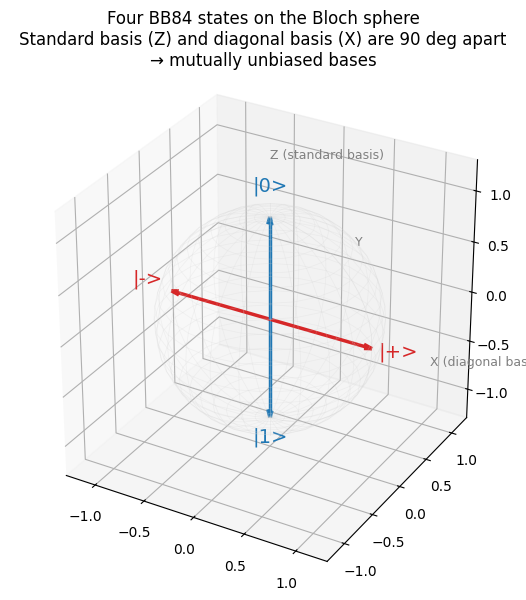


Example circuit — Alice encodes bit=1 in diagonal basis (prepares |->):

Case A: Bob measures in the SAME (diagonal) basis. Outcome is deterministic = 1.
     ┌───┐┌───┐ channel ┌───┐┌─┐
  q: ┤ X ├┤ H ├────░────┤ H ├┤M├
     └───┘└───┘    ░    └───┘└╥┘
c: 1/═════════════════════════╩═
                              0 

Case B: Bob measures in a MISMATCHED (standard) basis. Outcome is 50/50.
     ┌───┐┌───┐ channel ┌─┐
  q: ┤ X ├┤ H ├────░────┤M├
     └───┘└───┘    ░    └╥┘
c: 1/════════════════════╩═
                         0 


In [7]:
# --- QUANTUM PRIMITIVES: states, geometry, and an example transmission ---
#
# Uses Statevector and array_to_latex (from the template imports) to display
# the actual quantum objects, plus a Bloch sphere and worked-example circuits.

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# (1) The randomness source — the state we measure for every quantum coin flip.
randomness_circuit = QuantumCircuit(1)
randomness_circuit.h(0)
sv_random = Statevector(randomness_circuit)
print("Source of quantum randomness — H|0>:")
display(array_to_latex(sv_random, prefix="H|0\\rangle = "))

# (2) The four BB84 prepared states, as Statevectors.
# Same gate sequence Alice uses (X if bit=1, then H if basis=diagonal),
# but evaluated symbolically as a state vector instead of being measured.
def bb84_statevector(bit, basis):
    qc = QuantumCircuit(1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return Statevector(qc)

print("\nThe four BB84 prepared states:")
for label, bit, basis, basis_name in [
    ("|0>", 0, 0, "standard"),
    ("|1>", 1, 0, "standard"),
    ("|+>", 0, 1, "diagonal"),
    ("|->", 1, 1, "diagonal"),
]:
    sv = bb84_statevector(bit, basis)
    print(f"\n  bit={bit}, basis={basis_name}:")
    display(array_to_latex(sv, prefix=f"{label} = "))

# (3) Bloch sphere — visualises why the two BB84 bases are mutually unbiased.
# Standard basis lives on the Z-axis; diagonal basis lives on the X-axis.
# A 90 degree separation on the Bloch sphere = pi/4 in state space =
# inner product 1/sqrt(2) between bases = measurement gives no info.
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

# Wireframe sphere as a backdrop
u, v = np.meshgrid(np.linspace(0, 2*np.pi, 25), np.linspace(0, np.pi, 25))
ax.plot_wireframe(np.cos(u) * np.sin(v),
                  np.sin(u) * np.sin(v),
                  np.cos(v),
                  color='lightgray', alpha=0.25, linewidth=0.5)

# Four BB84 state vectors with text labels
state_vectors = [
    ('|0>',   0,  0,  1, '#1f77b4'),   # +Z  (standard basis, bit 0)
    ('|1>',   0,  0, -1, '#1f77b4'),   # -Z  (standard basis, bit 1)
    ('|+>',   1,  0,  0, '#d62728'),   # +X  (diagonal basis, bit 0)
    ('|->',  -1,  0,  0, '#d62728'),   # -X  (diagonal basis, bit 1)
]
for label, x, y, z, color in state_vectors:
    ax.quiver(0, 0, 0, x, y, z, color=color,
              arrow_length_ratio=0.08, linewidth=2.5)
    ax.text(x * 1.25, y * 1.25, z * 1.25, label,
            fontsize=14, color=color, ha='center')

# Axis hints
ax.text(1.55, 0,    0,    'X (diagonal basis)', fontsize=9, color='gray')
ax.text(0,    1.55, 0,    'Y',                  fontsize=9, color='gray')
ax.text(0,    0,    1.55, 'Z (standard basis)', fontsize=9, color='gray')

ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])
ax.set_zlim([-1.3, 1.3])
try:
    ax.set_box_aspect([1, 1, 1])
except AttributeError:
    pass  # older matplotlib versions
ax.set_title("Four BB84 states on the Bloch sphere\n"
             "Standard basis (Z) and diagonal basis (X) are 90 deg apart\n"
             "→ mutually unbiased bases")
plt.tight_layout()
plt.show()

# (4) Example BB84 transmission circuits, drawn out.
# Alice always prepares bit=1 in the diagonal basis (state |->).
# Bob's measurement basis varies, so the outcome behaviour differs.
print("\nExample circuit — Alice encodes bit=1 in diagonal basis (prepares |->):\n")

print("Case A: Bob measures in the SAME (diagonal) basis. Outcome is deterministic = 1.")
ex_match = QuantumCircuit(1, 1)
ex_match.x(0)                              # Alice: bit=1 -> |1>
ex_match.h(0)                              # Alice: diagonal basis -> |->
ex_match.barrier(label="channel")
ex_match.h(0)                              # Bob: diagonal-basis measurement
ex_match.measure(0, 0)
print(ex_match.draw())

print("\nCase B: Bob measures in a MISMATCHED (standard) basis. Outcome is 50/50.")
ex_mismatch = QuantumCircuit(1, 1)
ex_mismatch.x(0)
ex_mismatch.h(0)
ex_mismatch.barrier(label="channel")
ex_mismatch.measure(0, 0)                  # Bob: standard-basis measurement
print(ex_mismatch.draw())

# Reassurance for the reader: the gate sequence on the left-hand side of the
# barrier in both circuits is identical -- only Bob's choice changes the
# outcome distribution. That's the entire BB84 security argument in one image.


In [8]:
# --- ALICE ---

# Quantum-random bit values to encode.
alice_bits  = quantum_random_bits(N_QUBITS)
# Quantum-random basis choices: 0 = standard (Z), 1 = diagonal (X).
alice_bases = quantum_random_bits(N_QUBITS)

def alice_prepare(bit, basis):
    """Prepare one qubit encoding `bit` in the chosen `basis`.

    Quantum logic:
      - X flips |0> to |1>, so it sets the bit value.
      - H rotates the standard basis to the diagonal basis: |0>->|+>, |1>->|->.
    """
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)          # encode bit value
    if basis == 1:
        qc.h(0)           # rotate into diagonal basis if requested
    return qc

# Alice produces one prepared circuit per bit. Each circuit is a qubit
# "in flight" that will be handed to the channel.
alice_qubits = [alice_prepare(b, ba) for b, ba in zip(alice_bits, alice_bases)]

print("Alice bits :", alice_bits)
print("Alice bases:", alice_bases, "  (0=standard, 1=diagonal)")


Alice bits : [1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0]
Alice bases: [1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1]   (0=standard, 1=diagonal)


In [10]:
# --- QUANTUM CHANNEL ---

# Pass-through channel: the qubits Bob gets are exactly what the
# Alice prepared. (No noise, no Eve in this notebook.)
channel_qubits = list(alice_qubits)
print(channel_qubits)

[<qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98fdd7fad0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98fdd7deb0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98fdd7cd70>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98fdd7e030>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98fdd7dfd0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98fdd7d310>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98fdd7cda0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98fdd7cfb0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98ffa9ff50>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98fdd7efc0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98fdd7ed20>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98fdd7f5c0>, <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7f98fdd7e840>, <qiskit.circuit.quantumcircuit.QuantumCircuit obje

In [11]:
# --- BOB ---

# Quantum-random basis choices (0 = standard, 1 = diagonal).
bob_bases = quantum_random_bits(N_QUBITS)

def bob_measure(qc, basis):
    """Measure the incoming qubit in the chosen basis and return the bit.

    Quantum logic:
      - For the diagonal basis we apply H before measuring, because that
        rotates |+>,|-> back into |0>,|1> in the computational basis.
      - We then measure in the computational basis (the only kind of
        measurement Qiskit's basic simulator does directly).
    """
    if basis == 1:
        qc.h(0)            # rotate from diagonal back to standard basis
    qc.measure(0, 0)
    result = simulator.run(transpile(qc, simulator), shots=1).result()
    counts = result.get_counts()
    return int(next(iter(counts)))

bob_bits = [bob_measure(qc, b) for qc, b in zip(channel_qubits, bob_bases)]

print("Bob bases:", bob_bases)
print("Bob bits :", bob_bits)


Bob bases: [1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0]
Bob bits : [1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0]
